In [2]:
import nilearn
from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import MultiNiftiLabelsMasker
import os
import requests
import csv
import pandas as pd
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import scipy
from scipy.stats import multivariate_normal
from scipy.spatial.distance import pdist, squareform
from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics.cluster import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.sparse.csgraph import minimum_spanning_tree
from collections import deque, defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
import collections
from collections import defaultdict, deque
import copy

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f'Using device: {device}')

Using device: cpu


In [4]:
# set the working directory to fmri_connectivity_trees root directory
home_base_dir = '/Users/aj/dmello_lab/fmri_connectivity_trees' # directory where repository lives at home computer
lab_base_dir = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees' # directory where repository lives at lab computer
utd_base_dir = '/mfs/io/groups/dmello/projects/dynamric/fmri_connectivity_trees'
biohpc_base_dir = '/project/greencenter/Lin_lab/s229618/fmri_connectivity_trees'

# set base directory depending on where the code is being run
base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir
base_dir = utd_base_dir if os.path.exists(utd_base_dir) else base_dir
base_dir = biohpc_base_dir if os.path.exists(biohpc_base_dir) else base_dir


# get schaefer
# schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17, resolution_mm=1, data_dir=None, base_url=None, resume=True, verbose=1)
# schaefer_coords = plotting.find_parcellation_cut_coords(labels_img=schaefer.maps)

subjects = [
            'MSC01', 
            'MSC02',
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]

sessions = [
    'func01', 
    'func02', 
    'func03', 
    'func04', 
    'func05', 
    'func06', 
    'func07', 
    'func08', 
    'func09', 
    'func10'
    ]
ids = ['rest']
motor_ids = ['motor_run-01', 'motor_run-02']
atlas = 'glasser360_SUIT_Thalamus_Brainstem'
atlas_subdir = 'glasser360_SUIT_Thalamus_Brainstem'

# get glasser labels
file_path = f'{base_dir}/atlases/glasser360/glasser360NodeNames.txt'
with open(file_path, 'r') as file:
    glasser_labels = file.readlines()

temp = []
for label in glasser_labels:    
    label = label.strip()
    # reform to match region dataframe below
    components = label.split('_')
    temp.append(components[1] + '_' + components[0][0])
   
glasser_labels = temp

# get glasser region list
glasser_region_list = pd.read_csv(f'{base_dir}/atlases/glasser360/HCP-MMP1_UniqueRegionList.csv')


# get suit labels
suit_labels = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.tsv', sep='\t')
suit_table = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.csv', sep='\t')

# get Thalamus labels
thalamus_labels = pd.read_csv(f'{base_dir}/atlases/Thalamus/ThalamusProbs.MNIsymSpace.names.txt', sep=',', header=None)[1]

# get Brainstem labels
brainstem_labels = pd.read_csv(f'{base_dir}/atlases/Brainstem/BrainstemProbs.MNIsymSpace.names.txt', sep=',', header=None)[1]


glasser_coords = []
for row in glasser_region_list.iterrows():
    glasser_coords.append([row[1]['x-cog'], row[1]['y-cog'], row[1]['z-cog']])

# all labels
all_labels = glasser_labels + suit_labels['name'].to_list()[:-2] + thalamus_labels.to_list() + brainstem_labels.to_list() # last two were resampled out

In [61]:
glasser_region_list['cortex']

0                                Primary_Visual
1      MT+_Complex_and_Neighboring_Visual_Areas
2                          Dorsal_Stream_Visual
3                                  Early_Visual
4                                  Early_Visual
                         ...                   
355                        Auditory_Association
356                            Lateral_Temporal
357               Insular_and_Frontal_Opercular
358    Anterior_Cingulate_and_Medial_Prefrontal
359    Anterior_Cingulate_and_Medial_Prefrontal
Name: cortex, Length: 360, dtype: object

In [ ]:
# suit_coords = []
# for row in suit_table.iterrows():
#     print(row)
    # suit_coords.append(row[1].split(' ')[1], row[1].split()[2], row[1].split()[3])

In [13]:
len(thalamus_labels)

53

In [12]:
glasser_region_list

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
0,V1_L,Primary_Visual_Cortex_L,1_L,L,V1,Occ,Primary_Visual,1,1,100.491589,41.138901,71.637040,6717
1,MST_L,Medial_Superior_Temporal_Area_L,2_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,2,5,132.416667,58.901786,82.059524,336
2,V6_L,Sixth_Visual_Area_L,3_L,L,V6,Occ,Dorsal_Stream_Visual,3,3,104.543112,44.481665,103.916749,1009
3,V2_L,Second_Visual_Area_L,4_L,L,V2,Occ,Early_Visual,4,2,102.236656,44.064791,74.401125,6220
4,V3_L,Third_Visual_Area_L,5_L,L,V3,Occ,Early_Visual,5,2,107.926111,40.632159,76.961153,4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,STSva_R,Area_STSv_anterior_R,376_R,R,STSva,Temp,Auditory_Association,376,11,32.924419,117.527907,54.337791,1720
356,TE1m_R,Area_TE1_Middle_R,377_R,R,TE1m,Temp,Lateral_Temporal,377,14,26.146605,102.236497,53.246528,2592
357,PI_R,Para-Insular_Area_R,378_R,R,PI,Temp,Insular_and_Frontal_Opercular,378,12,47.013363,123.157016,57.926503,898
358,a32pr_R,Area_anterior_32_prime_R,379_R,R,a32pr,Fr,Anterior_Cingulate_and_Medial_Prefrontal,379,19,81.723096,153.990326,102.516324,827


In [10]:
glasser_cort_regions = np.unique(glasser_region_list['cortex'])

In [11]:
glasser_cort_regions

array(['Anterior_Cingulate_and_Medial_Prefrontal', 'Auditory_Association',
       'Dorsal_Stream_Visual', 'Dorsolateral_Prefrontal',
       'Early_Auditory', 'Early_Visual', 'Inferior_Frontal',
       'Inferior_Parietal', 'Insular_and_Frontal_Opercular',
       'Lateral_Temporal', 'MT+_Complex_and_Neighboring_Visual_Areas',
       'Medial_Temporal', 'Orbital_and_Polar_Frontal',
       'Paracentral_Lobular_and_Mid_Cingulate', 'Posterior_Cingulate',
       'Posterior_Opercular', 'Premotor', 'Primary_Visual',
       'Somatosensory_and_Motor', 'Superior_Parietal',
       'Temporo-Parieto-Occipital_Junction',
       'Temporo-Parieto_Occipital_Junction', 'Ventral_Stream_Visual'],
      dtype=object)

In [5]:
def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=100):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'

        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data

def plot_connectome(cov_matrix, coords, title='connectome', edge_threshold="0%", edge_vmin=0, edge_vmax=1):
    """
    Plot the connectome using the mean correlation matrix and coordinates.
    """
    # Plotting the connectome
    plotting.plot_connectome(
        cov_matrix,
        coords,
        title=title,
        edge_vmin = edge_vmin,
        edge_vmax = edge_vmax,
        edge_cmap='cold_hot',
        edge_threshold=edge_threshold,  # Only plot edges above the 90th percentile
        colorbar=True,
        node_size=10,
    )
    plt.show()

def mi_to_graph(mi, selected_nodes=None):
    
    # Create a graph
    G = nx.Graph()
    num_variables = mi.shape[0]
    
    if selected_nodes is not None:
        for i in selected_nodes:
            G.add_node(i)
        
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(selected_nodes[i], selected_nodes[j], weight=mi[i, j])

    else:
        # Add nodes (variables)
        for i in range(num_variables):
            G.add_node(i)

    # Add edges with mutual information as weights
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(i, j, weight=mi[i, j])
    
    return G

def chow_liu_tree(mi):
    
    # Create a graph
    G = mi_to_graph(mi)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_chow_liu_trees(mi, joint_probs, subjects=subjects):

    cl_trees = {}
    cl_matrices = {}
    cl_joint_probs = {}
    for subject in subjects:
        _, cl_trees[subject] = chow_liu_tree(mi[subject])
        cl_matrices[subject] = torch.from_numpy(nx.to_numpy_array(cl_trees[subject], weight='weight'))
        cl_joint_probs[subject] = {}
        for edge in cl_trees[subject].edges():
            i, j = edge
            cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return cl_trees, cl_matrices, cl_joint_probs

def draw_chow_liu_tree(G, root=0):
    """
    Visualize the Chow-Liu tree using a spring layout (no pygraphviz).
    """
    tree = nx.bfs_tree(G, source=root)
    pos = nx.spring_layout(tree, seed=42)

    plt.figure(figsize=(8, 6))
    nx.draw(tree, pos, with_labels=True, arrows=False, node_color="lightblue", 
            edge_color="black", node_size=1500, font_size=12)
    
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels)

    plt.title("Chow-Liu Tree (Spring Layout)")
    plt.axis("off")
    plt.show()


def hierarchy_pos(G, root=None, width=1., vert_gap=0.5, vert_loc=0, xcenter=0.5):
    """
    Hierarchical layout for directed trees. Assigns space to subtrees to avoid squishing.
    """
    def _count_descendants(G, node):
        children = list(G.successors(node))
        if not children:
            return 1
        return sum(_count_descendants(G, child) for child in children)

    def _hierarchy_pos(G, node, left, right, vert_loc, pos):
        center = (left + right) / 2
        pos[node] = (center, vert_loc)
        children = list(G.successors(node))
        if children:
            total = sum(_count_descendants(G, child) for child in children)
            dx = (right - left) / total
            next_left = left
            for child in children:
                size = _count_descendants(G, child)
                next_right = next_left + dx * size
                pos = _hierarchy_pos(G, child, next_left, next_right, vert_loc - vert_gap, pos)
                next_left = next_right
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, {})

def get_node_regions(tree, network_labels=None, region_labels=None, atlas_name='schaefer'):

    if atlas_name == 'schaefer':
        networks = []
        for node in tree.nodes:
            network = str(network_labels[node]).split('_')[2]
            networks.append(network)
        return networks
    
    elif atlas_name == 'glasser_suit':
        networks = []
        network_labels = list(region_labels) + ['Cerebellum']*32
        for node in tree.nodes:
            network = network_labels[node]
            networks.append(network)
        return networks
    
    elif atlas_name == 'glasser360_SUIT_Thalamus_Brainstem':
        networks = []
        network_labels = list(region_labels) + ['Cerebellum']*32 + ['Thalamus']*53 + ['Brainstem_background', 'Medulla', 'Pons', 'SCP', 'Midbrain']
        for node in tree.nodes:
            network = network_labels[node]
            networks.append(network)
        return networks
    
def draw_hierarchical_tree(G, root=0, atlas_name='glasser_suit', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title = "Hierarchical Chow-Liu Tree"):
    """
    Draw Chow-Liu tree in a hierarchical top-down format.
    """
    # Ensure it's a directed tree rooted at `root`
    tree = nx.bfs_tree(G, source=root)

    pos = hierarchy_pos(tree, root)
    if atlas_name == 'schaefer':
        networks = get_node_regions(tree, atlas_name='schaefer', network_labels=schaefer.labels)
    
    elif atlas_name == 'glasser_suit':
        networks = get_node_regions(tree, atlas_name='glasser_suit', region_labels=glasser_region_list['cortex'])
    
    elif atlas_name == 'glasser360_SUIT_Thalamus_Brainstem':
        networks = get_node_regions(tree, atlas_name='glasser360_SUIT_Thalamus_Brainstem', region_labels=glasser_region_list['cortex'])

    if atlas_name == 'schaefer':
        # Create a color map based on the networks

        network_names = ['Cont', 'Default', 'DorsAttn', 'Limbic', 'SalVentAttn', 'SomMot', 'Vis']
        colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
        
        if num_schaefer_networks == 17:
            network_names = ['ContA',
                            'ContB',
                            'ContC',
                            'DefaultA',
                            'DefaultB',
                            'DefaultC',
                            'DorsAttnA',
                            'DorsAttnB',
                            'LimbicA',
                            'LimbicB',
                            'SalVentAttnA',
                            'SalVentAttnB',
                            'SomMotA',
                            'SomMotB',
                            'TempPar',
                            'VisCent',
                            'VisPeri']
            
            colors = colors = [
                                "#e6194b",  # red
                                "#3cb44b",  # green
                                "#ffe119",  # yellow
                                "#4363d8",  # blue
                                "#f58231",  # orange
                                "#911eb4",  # purple
                                "#46f0f0",  # cyan
                                "#f032e6",  # magenta
                                "#bcf60c",  # lime
                                "#fabebe",  # pink
                                "#008080",  # teal
                                "#e6beff",  # lavender
                                "#9a6324",  # brown
                                "#fffac8",  # beige
                                "#800000",  # maroon
                                "#aaffc3",  # mint
                                "#808000",  # olive      
                            ]
    
    if atlas_name == 'glasser_suit':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum']
        colors =          [
                            "#e6194b",  # red
                            "#3cb44b",  # green
                            "#ffe119",  # yellow
                            "#4363d8",  # blue
                            "#f58231",  # orange
                            "#911eb4",  # purple
                            "#46f0f0",  # cyan
                            "#f032e6",  # magenta
                            "#bcf60c",  # lime
                            "#fabebe",  # pink
                            "#008080",  # teal
                            "#e6beff",  # lavender
                            "#9a6324",  # brown
                            "#fffac8",  # beige
                            "#800000",  # maroon
                            "#aaffc3",  # mint
                            "#808000",  # olive
                            "#000075",  # navy
                            "#ffd8b1",  # peach
                            "#469990",  # turquoise
                            "#000000",  # black
                            "#ffffff",  # white
                            "#d2691e",  # chocolate
                            "#ff7f50",  # coral
                        ]
    if atlas_name == 'glasser360_SUIT_Thalamus_Brainstem':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus', 'Brainstem_background', 'Medulla', 'Pons', 'SCP', 'Midbrain']

        colors =          [
                            "#e6194b",  # red
                            "#3cb44b",  # green
                            "#ffe119",  # yellow
                            "#4363d8",  # blue
                            "#f58231",  # orange
                            "#911eb4",  # purple
                            "#46f0f0",  # cyan
                            "#f032e6",  # magenta
                            "#bcf60c",  # lime
                            "#fabebe",  # pink
                            "#008080",  # teal
                            "#e6beff",  # lavender
                            "#9a6324",  # brown
                            "#fffac8",  # beige
                            "#800000",  # maroon
                            "#aaffc3",  # mint
                            "#808000",  # olive
                            "#000075",  # navy
                            "#ffd8b1",  # peach
                            "#469990",  # turquoise
                            "#000000",  # black
                            "#ffffff",  # white
                            "#d2691e",  # chocolate
                            "#ff7f50",  # coral
                            "#40e0d0",  # turquoise bright
                            "#ff1493",  # deep pink
                            "#7fff00",  # chartreuse
                            "#1e90ff",  # dodger blue
                            "#ff4500",  # orange red
                            "#daa520",  # goldenrod
                        ]

    color_map = []
    print(networks)
    for node, network in zip(tree.nodes, networks):
        if network in network_names:
            color = colors[network_names.index(network)]
            color_map.append(color)
        else:
            color_map.append('white')
    # print(color_map)
    
    # color_map = np.array(color_map)
    # color_map = color_map / max(color_map)
    
    plt.figure(figsize=(10, 6))
    nx.draw(tree, pos, with_labels=True, node_color=color_map, node_size=140,
            arrows=False, font_size=6, edge_color='gray')


    # edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    # nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size = 0)

    patches = [mpatches.Patch(color=color, label=network_name) for color, network_name in zip(colors, network_names)]
    plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

    return tree, pos, network_names, colors

In [6]:
def select_networks_schaefer(schaefer, networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    selected_nodes = []
    for i, label in enumerate(schaefer.labels):
        network = str(label).split('_')[2]
        if network in networks:
            selected_nodes.append(i)
    return selected_nodes

def select_networks_glasser(labels=list(glasser_region_list['cortex'])+['Cerebellum']*32, networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum']):
    
    selected_nodes = []
    node_names = []
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return selected_nodes

def select_networks_glasser360_SUIT_Thalamus_Brainstem(labels=list(glasser_region_list['cortex']) + ['Cerebellum']*32 + ['Thalamus']*53 + ['Brainstem_background', 'Medulla', 'Pons', 'SCP', 'Midbrain'], networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Thalamus', 'Pons']):
    
    selected_nodes = []
    node_names = []
    print(labels)
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return node_names, selected_nodes

def selective_chow_liu_tree(mi, selected_nodes):
    
    # Create a graph
    selected_mi = mi[np.ix_(selected_nodes, selected_nodes)]
    
    G = mi_to_graph(selected_mi, selected_nodes=selected_nodes)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_selective_chow_liu_trees(mi, joint_probs, subjects=subjects, atlas_name='glasser_suit', schaefer=None, selected_networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    if atlas_name == 'schaefer':
        node_names, selected_nodes = select_networks_schaefer(schaefer, networks=selected_networks)
    
    if atlas_name == 'glasser_suit':
        node_names, selected_nodes = select_networks_glasser(networks=selected_networks)
    
    if atlas_name == 'glasser360_SUIT_Thalamus_Brainstem':
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus_Brainstem(networks=selected_networks)

    print(node_names)
    print(selected_nodes)
    selective_cl_trees = {}
    selective_cl_joint_probs = {}
    
    for subject in subjects:
        _, selective_cl_trees[subject] = selective_chow_liu_tree(mi[subject], selected_nodes=selected_nodes)
        selective_cl_joint_probs[subject] = {}
        for edge in selective_cl_trees[subject].edges():
            i, j = edge
            selective_cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return selective_cl_trees, selective_cl_joint_probs, selected_nodes

In [7]:
subjects = [
            'MSC01', 
            'MSC02',
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]

task = 'rest'

mi = load_data(subjects=subjects, measure="mutual_information", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)
mi_joint_probs = load_data(subjects=subjects, measure="joint_probs", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)
product_of_marginals = load_data(subjects=subjects, measure="product_of_marginals", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=100)

In [8]:
max(mi_joint_probs['MSC05'][0][1].flatten())

tensor(0.0067)

In [9]:
cl_trees, cl_matrices, cl_joint_probs = get_chow_liu_trees(mi, mi_joint_probs, subjects=subjects)

In [10]:
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi, mi_joint_probs, atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=subjects, selected_networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Thalamus', 'Pons'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

In [24]:
def get_sum(subjects, subject_data):

    sum_mat = subject_data[subjects[0]]
    for subject in subjects[1:]:
        sum_mat += subject_data[subject]
    
    sum_dict = {"Total": sum_mat}
    
    return sum_dict
        

In [32]:
mi_total = get_sum(subjects, mi)

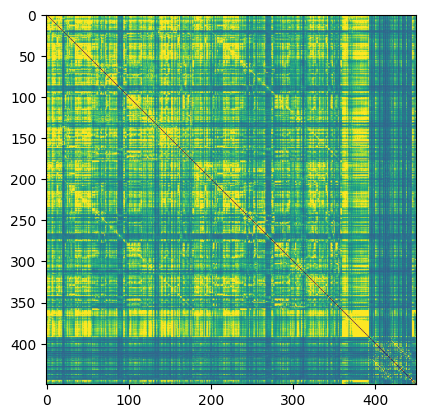

In [55]:
plt.imshow(mi_total['Total']/len(subjects), cmap='viridis', vmin=0, vmax=1)

In [25]:
total_cl_tree, total_cl_matrix, total_cl_joint_probs = get_chow_liu_trees(get_sum(subjects, mi), get_sum(subjects, mi_joint_probs), subjects=['Total'])

In [28]:
selective_total_tree, selective_total_joint_probs, selected_nodes = get_selective_chow_liu_trees(get_sum(subjects, mi), get_sum(subjects, mi_joint_probs), atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=['Total'], selected_networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Thalamus', 'Pons'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

['Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Inferior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Superior_Parietal', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Temporo-Parieto-Occipital_Junction', 'Posterior_Cingulate', 'Superior_Parietal', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Superior_Parietal', 'Inferior_Parietal', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Inferior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Inferior_Parietal', 'Posterior_Cingulate', 'Dorsolateral_Prefrontal', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Inferior_Parietal', 'Inferior_Parietal', 'Inferior_Parietal', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Vi

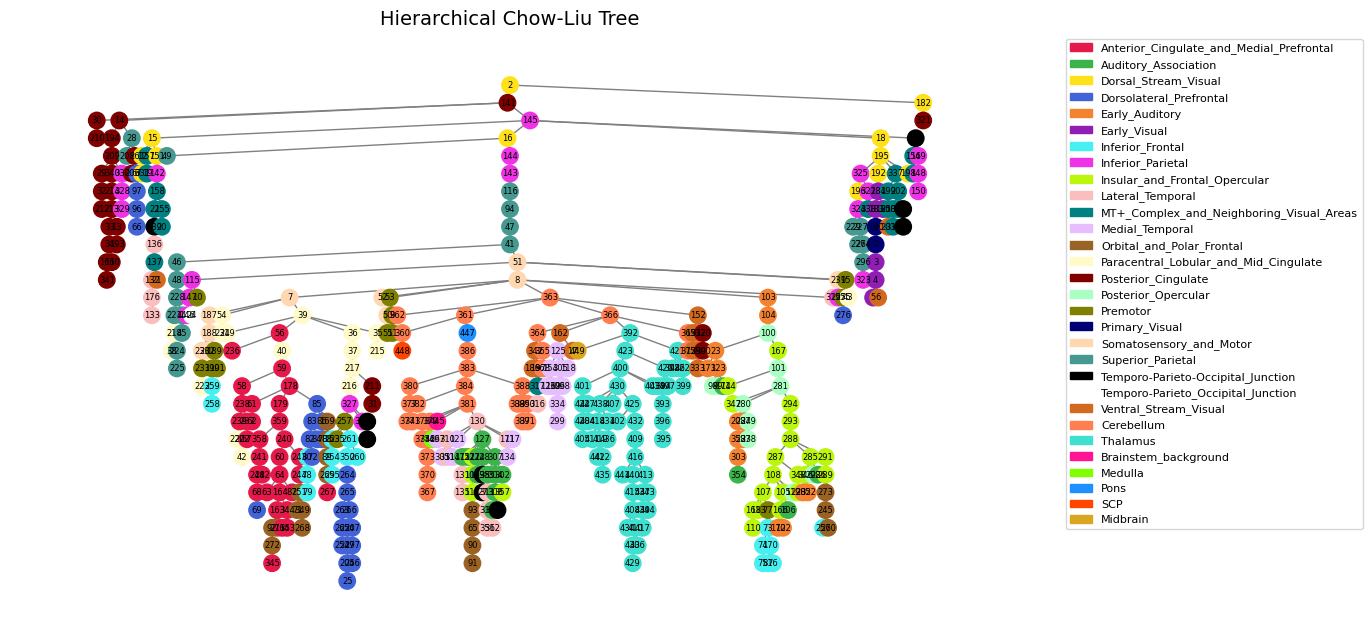

In [26]:
tree, pos, network_names, colors = draw_hierarchical_tree(total_cl_tree['Total'], atlas_name = 'glasser360_SUIT_Thalamus_Brainstem', root=2)

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Premotor', 'Premotor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Premotor', 'Premotor', 'Premotor', 'Premotor', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Premotor', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Premotor', 'Pons', 'Thalamus', 'Thalamus', 'Thalamus', 'Premotor', 'Cerebellum', 'Cerebellum', 'Premotor', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Cerebell

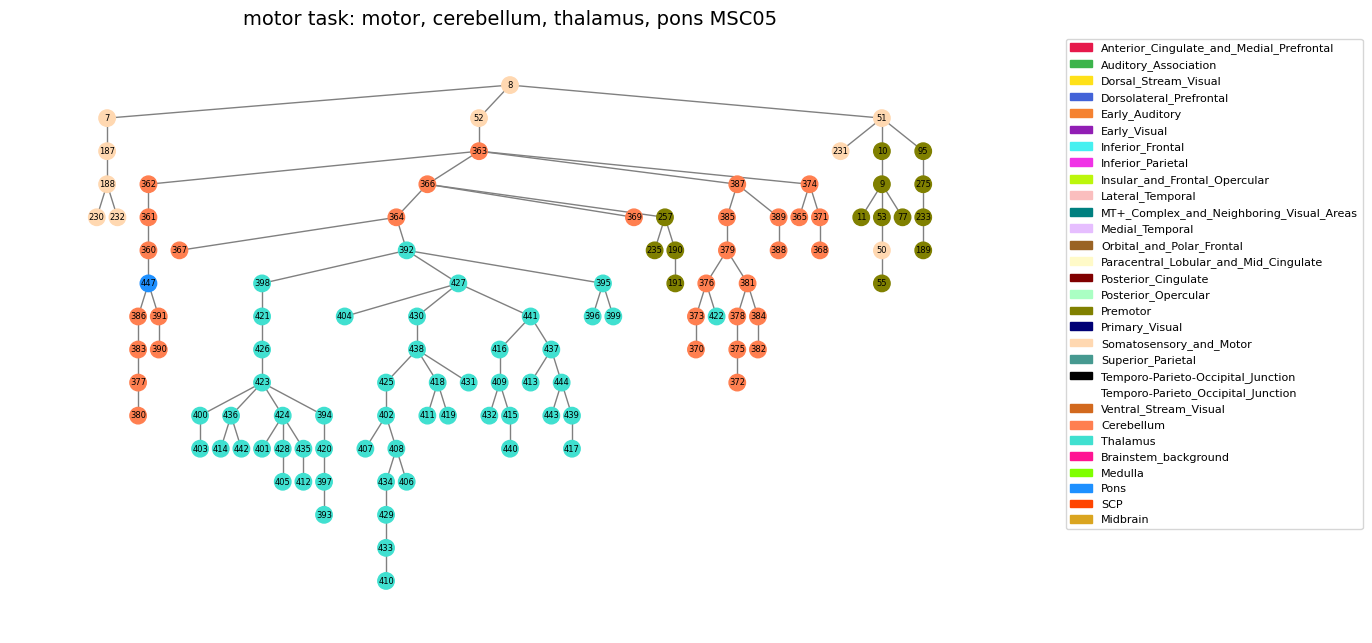

In [13]:
subject = 'MSC05'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 8
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees[subject], atlas_name = 'glasser360_SUIT_Thalamus_Brainstem', root=root, title=f"motor task: motor, cerebellum, thalamus, pons {subject}")

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Cerebellum', 'Premotor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Somatosensory_and_Motor', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Cerebellum', 'Pons', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Cerebellum', 'Thalamus', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Premotor', 'Premotor', 'Premotor', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalam

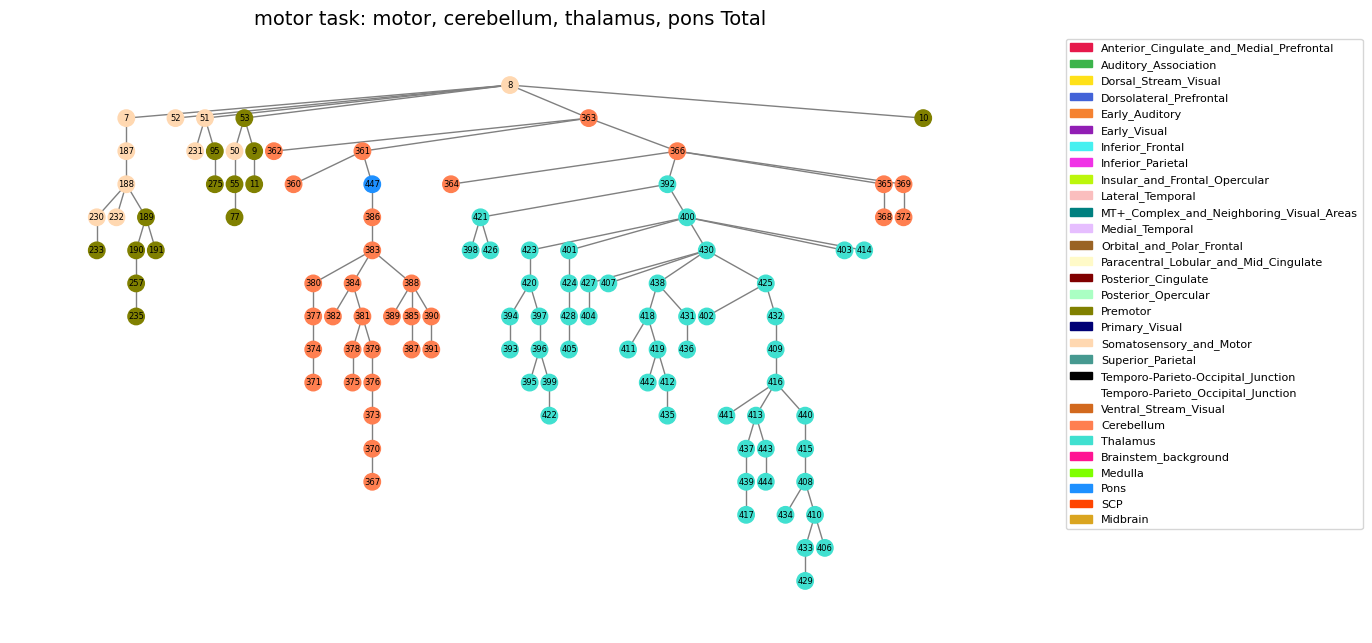

In [31]:
subject = 'Total'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 8
tree, pos, network_names, colors = draw_hierarchical_tree(selective_total_tree[subject], atlas_name = 'glasser360_SUIT_Thalamus_Brainstem', root=root, title=f"motor task: motor, cerebellum, thalamus, pons {subject}")

In [68]:
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi, mi_joint_probs, atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=subjects, selected_networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

In [69]:
len(selected_nodes)

56

In [66]:
selective_cl_trees['MSC01'].nodes

NodeView((7, 8, 9, 10, 11, 50, 51, 52, 53, 55, 77, 95, 187, 188, 189, 190, 191, 230, 231, 232, 233, 235, 257, 275, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 447))

In [71]:
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi, mi_joint_probs, atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=subjects, selected_networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Premotor', 'Somatosensory_and_Motor', 'Premotor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Premotor', 'Premotor', 'Premotor', 'Premotor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Premotor', 'Premotor', 'Premotor', 'Somatosensory_and_Motor', 'Premotor', 'Cerebellum', 'Pons', 'Thalamus', 'Premotor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Premotor', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Ce

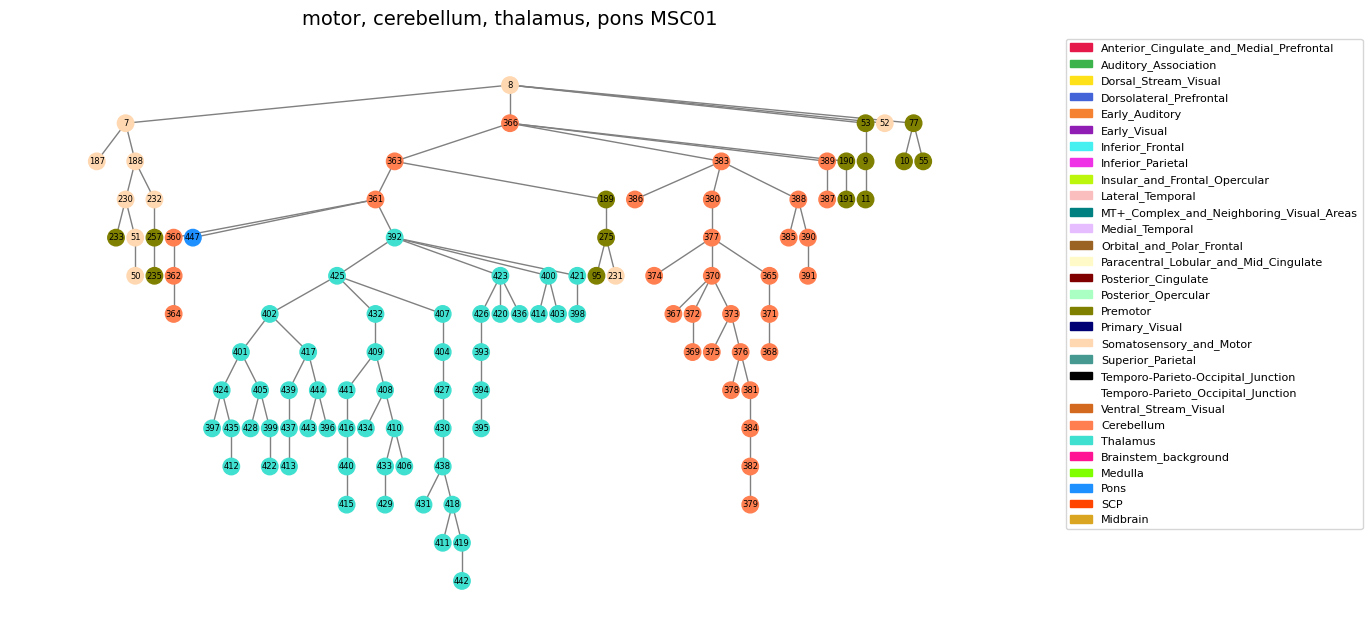

In [20]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC01'], atlas_name = 'glasser360_SUIT_Thalamus_Brainstem', root=list(selective_cl_trees['MSC01'].nodes)[1], title="motor, cerebellum, thalamus, pons MSC01")

In [194]:
print(glasser_region_list['regionLongName'][190])
print(glasser_region_list['regionLongName'][235])
print(glasser_region_list['regionLongName'][257])

Premotor_Eye_Field_R
Ventral_Area_6_R
Rostral_Area_6_R


In [111]:
selective_cl_trees['MSC09'].nodes

NodeView((7, 8, 9, 10, 11, 50, 51, 52, 53, 55, 77, 95, 187, 188, 189, 190, 191, 230, 231, 232, 233, 235, 257, 275))

ValueError: Shape mismatch between 'adjacency_matrix' and 'node_coords'.'adjacency_matrix' shape is (392, 392), 'node_coords' shape is (100, 3).

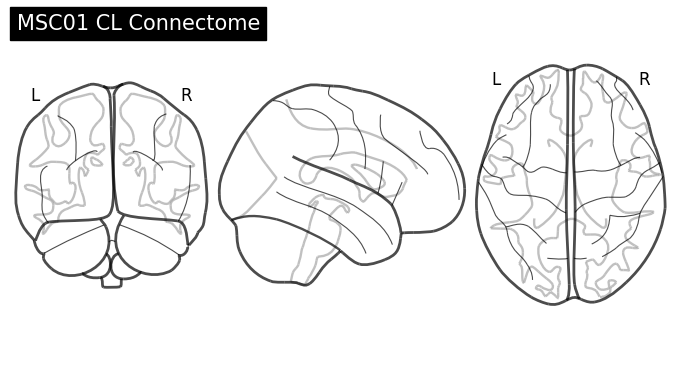

In [195]:
plot_connectome(nx.to_numpy_array(cl_trees['MSC01']), schaefer_coords, title='MSC01 CL Connectome', edge_threshold="0%", edge_vmax=max(mi['MSC03'].flatten()), edge_vmin=min(mi['MSC03'].flatten()))

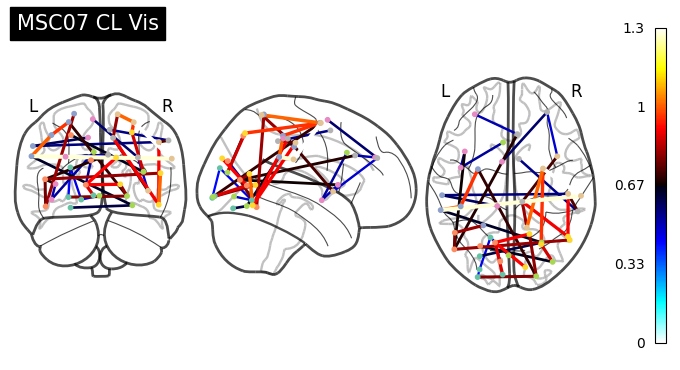

In [116]:
plot_connectome(nx.to_numpy_array(selective_cl_trees['MSC07']), schaefer_coords[selected_nodes], title='MSC07 CL Vis', edge_threshold="0%", edge_vmax=max(mi['MSC07'].flatten()), edge_vmin=min(mi['MSC03'].flatten()))

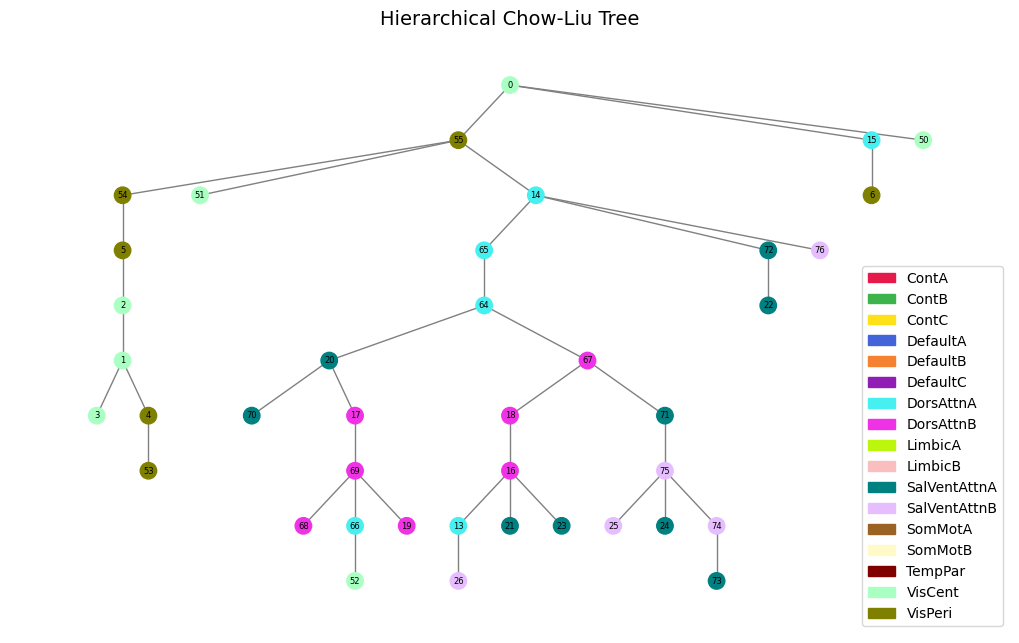

In [71]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC03'], root=0)

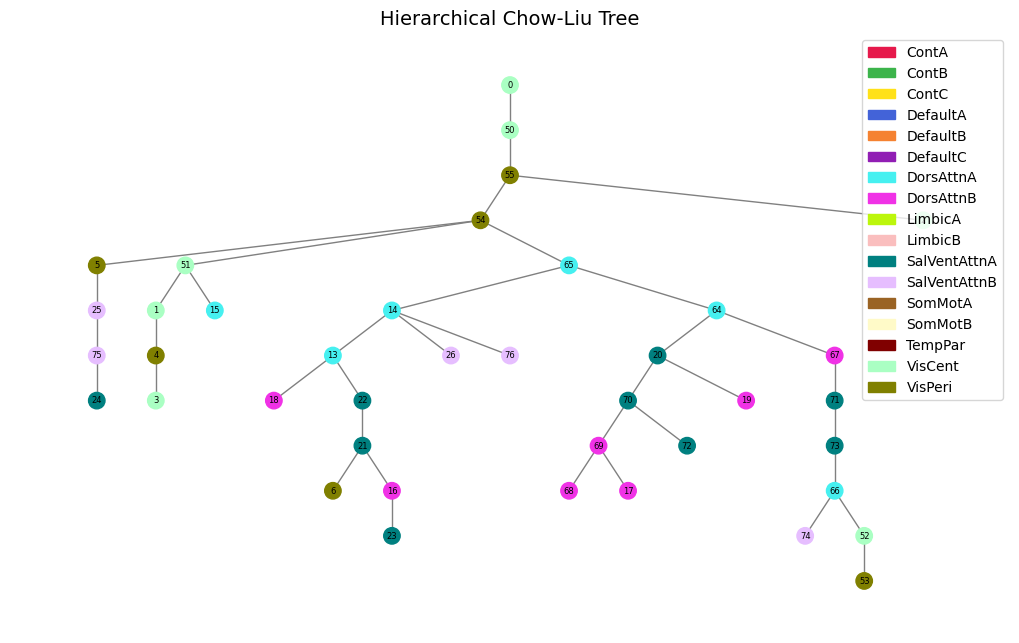

In [182]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC04'], root=0)

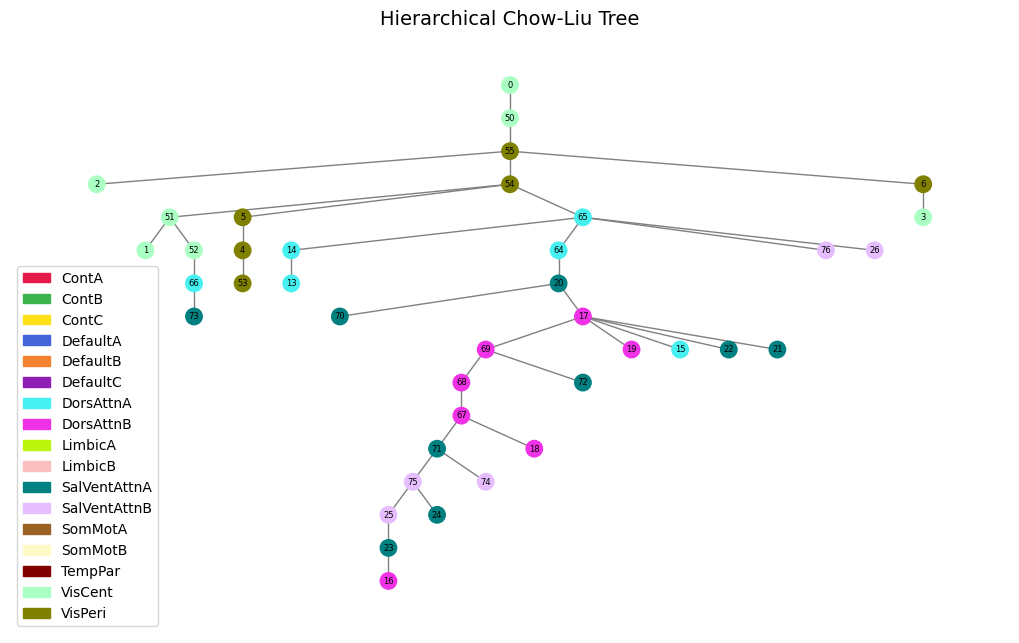

In [74]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC05'], root=0)

In [19]:
tree, pos, network_names, colors = draw_hierarchical_tree(cl_trees['MSC03'], root=0)

IndexError: list index out of range

In [12]:
def derive_joint_probs_abc(a, b, c, joint_probs):
    """
    Get the joint probability of three variables a, b, and c.
    Given that a and b exists, b and c exists, but a and c does not exist
    """
    # p_ab = cl_joint_probs[subject][(a, b)]
    # p_bc = cl_joint_probs[subject][(b, c)]
    # p_b = np.sum(p_bc, axis=1)
    # p_cb_conditional = p_bc / (p_b[:, None] + 1e-10)  # Avoid division by zero
        # Add a check for the keys to prevent KeyError
        
    return joint_probs[(a, b)][:, :, None] * (joint_probs[(b, c)] / joint_probs[(b, c)].sum(axis=1)[:, None] + 1e-10)[None, :, :]

# marginalize by integrating over b
def marginalize_over_b(p_abc):
    """
    Marginalize the joint probability p_abc over b to get p_ac.
    p_abc is a 3D array with shape (num_bins_a, num_bins_b, num_bins_c)
    """
    return p_abc.sum(axis=1)

# derive mutual information from joint probability
def derive_mutual_info(p_ac):
    
    return torch.sum(p_ac * torch.log(p_ac / torch.outer(p_ac.sum(axis=1), p_ac.sum(axis=0)) + 1e-10))
                    


In [13]:
def cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, subject='MSC01', selected_nodes=None, selective_cl_trees=None, selective_cl_joint_probs=None):    

    """
    Traverse the Chow-Liu tree and reconstruct the mutual information matrix.  
    """
    
    if selected_nodes is None:
        joint_probs = copy.deepcopy(cl_joint_probs[subject])
        tree = cl_trees[subject].copy()
        cl_matrix = cl_matrices[subject].clone().to(device)
        mi_recon = cl_matrix.clone().to(device)
    
    ## TO DO ##
    elif selected_nodes is not None:
        if selective_cl_trees is None:
            raise ValueError("selective_cl_trees must be provided when selected_nodes is specified.")
        if selective_cl_joint_probs is None:
            raise ValueError("selective_cl_trees must be provided when selected_nodes is specified.")
        joint_probs = copy.deepcopy(selective_cl_joint_probs[subject])
        tree = selective_cl_trees[subject].copy()
        # cl_matrix = torch.from_numpy(nx.to_numpy_array(tree, weight='weight'))
       
    # mi_recon = cl_matrices[subject].clone().to(device) 
    visited = []
    
    # add first node in the tree to start traversal
    nodes = [list(tree.nodes)[0]]

    calc_bool = cl_matrices[subject].bool().to(device)
    
    if selected_nodes is not None:
        
        cl_matrix = torch.zeros_like(cl_matrices[subject]).to(device)
        mi_recon = torch.zeros_like(cl_matrices[subject]).to(device)
        
        for i, j in tree.edges():
            mi_recon[i, j] = tree[i][j]['weight']
            cl_matrix[i, j] = tree[i][j]['weight']
            
        calc_bool = calc_bool.fill_(True)
        for node in selected_nodes:
            for node_2 in selected_nodes[1:]:
                calc_bool[node, node_2] = False

    
    calc_bool.fill_diagonal_(True)  # Set diagonal to True since MI of a variable with itself is 0
        

    while False in calc_bool:

        # print(nodes)
        if len(nodes) == 0:
            break
        
        parent = nodes.pop()
        break_now = False
        
        while parent in visited:
           
            if parent in visited and len(nodes) == 0:
                break_now = True
                break
        
            parent = nodes.pop()
        
        if break_now:
            break
            
        visited.append(parent)
        print("# MI calculated: ", calc_bool.sum() / (calc_bool.shape[0] * calc_bool.shape[1]))
        print("parent: ", parent)
        children = list(tree.neighbors(parent))
        # nodes = nodes + children
        #print(children)
        
        for child in children:
            if child not in visited:
                nodes.append(child)

        while children: 

            child = children.pop()
            # print("child: ", child)
            
            # if child not in nodes and len(children) == 0:
            #     # nodes.append(child)

            # make sure edge goes both ways
            if (child, parent) not in tree.edges():
                tree.add_edge(child, parent)

            # print("child, parent: ", child, parent)

            if joint_probs.get((parent, child)) is None:
                joint_probs[(parent, child)] = joint_probs[(child, parent)].clone().to(device).T
            
            elif joint_probs.get((child, parent)) is None:
                joint_probs[(child, parent)] = joint_probs[(parent, child)].clone().to(device).T

            for sibling in children:
                # print("child, sibling: ", child, sibling)
                if calc_bool[child, sibling]:
                    continue
                
                if child not in nodes:
                    nodes.append(child)

                if joint_probs.get((parent, sibling)) is None:
                    joint_probs[(parent, sibling)] = joint_probs[(sibling, parent)].clone().to(device).T
            
                elif joint_probs.get((sibling, parent)) is None:
                    joint_probs[(sibling, parent)] = joint_probs[(parent, sibling)].clone().to(device).T

                # connect child to all its "siblings" through the mutual "parent"
                joint_prob_all = derive_joint_probs_abc(child, parent, sibling, joint_probs)
                joint_probs[(child, sibling)] = marginalize_over_b(joint_prob_all)
                joint_probs[(sibling, child)] = joint_probs[(child, sibling)].clone().to(device).T
                mi_recon[child, sibling] = derive_mutual_info(joint_probs[(child, sibling)])
                mi_recon[sibling, child] = mi_recon[child, sibling]

                # add to tree
                tree.add_edge(child, sibling)
                tree.add_edge(sibling, child)

                # mark MI as calculated
                calc_bool[child, sibling], calc_bool[sibling, child] = True, True

                # if child not in nodes:
                #     nodes.append(child)
            
            # nodes.append(child)
    
    if selected_nodes is not None:
        return mi_recon[np.ix_(selected_nodes, selected_nodes)], joint_probs
    
    return mi_recon, joint_probs

In [14]:
smi_recon, sjoint_probs = cl_tree_traversal(cl_joint_probs, selective_cl_trees, cl_matrices, 'MSC03', selective_cl_trees=selective_cl_trees, selective_cl_joint_probs=selective_cl_joint_probs, selected_nodes=selected_nodes)

# MI calculated:  tensor(0.9413)
parent:  7
# MI calculated:  tensor(0.9413)
parent:  188
# MI calculated:  tensor(0.9414)
parent:  8
# MI calculated:  tensor(0.9417)
parent:  189
# MI calculated:  tensor(0.9420)
parent:  9
# MI calculated:  tensor(0.9420)
parent:  191
# MI calculated:  tensor(0.9420)
parent:  233
# MI calculated:  tensor(0.9420)
parent:  187
# MI calculated:  tensor(0.9420)
parent:  51
# MI calculated:  tensor(0.9423)
parent:  379
# MI calculated:  tensor(0.9428)
parent:  55
# MI calculated:  tensor(0.9434)
parent:  382
# MI calculated:  tensor(0.9438)
parent:  77
# MI calculated:  tensor(0.9438)
parent:  384
# MI calculated:  tensor(0.9438)
parent:  370
# MI calculated:  tensor(0.9443)
parent:  231
# MI calculated:  tensor(0.9443)
parent:  372
# MI calculated:  tensor(0.9445)
parent:  367
# MI calculated:  tensor(0.9445)
parent:  369
# MI calculated:  tensor(0.9445)
parent:  50
# MI calculated:  tensor(0.9448)
parent:  11
# MI calculated:  tensor(0.9448)
parent:  230

In [15]:
mi_recon, joint_probs = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, 'MSC03')

# MI calculated:  tensor(0.0067)
parent:  0
# MI calculated:  tensor(0.0067)
parent:  180
# MI calculated:  tensor(0.0067)
parent:  3
# MI calculated:  tensor(0.0068)
parent:  183
# MI calculated:  tensor(0.0068)
parent:  368
# MI calculated:  tensor(0.0068)
parent:  5
# MI calculated:  tensor(0.0069)
parent:  4
# MI calculated:  tensor(0.0071)
parent:  19
# MI calculated:  tensor(0.0071)
parent:  153
# MI calculated:  tensor(0.0071)
parent:  366
# MI calculated:  tensor(0.0073)
parent:  184
# MI calculated:  tensor(0.0076)
parent:  364
# MI calculated:  tensor(0.0085)
parent:  192
# MI calculated:  tensor(0.0085)
parent:  420
# MI calculated:  tensor(0.0085)
parent:  392
# MI calculated:  tensor(0.0094)
parent:  365
# MI calculated:  tensor(0.0096)
parent:  449
# MI calculated:  tensor(0.0099)
parent:  374
# MI calculated:  tensor(0.0101)
parent:  395
# MI calculated:  tensor(0.0104)
parent:  371
# MI calculated:  tensor(0.0104)
parent:  396
# MI calculated:  tensor(0.0104)
parent:  3

In [47]:
cl_trees['MSC01'].edges()

EdgeView([(0, 2), (0, 91), (0, 50), (0, 24), (1, 54), (1, 4), (2, 55), (2, 76), (2, 15), (3, 4), (3, 53), (5, 54), (5, 55), (6, 39), (6, 7), (7, 57), (8, 57), (9, 11), (9, 10), (10, 59), (10, 23), (12, 61), (13, 22), (14, 65), (14, 20), (15, 32), (16, 22), (16, 21), (17, 69), (18, 33), (18, 22), (19, 35), (20, 70), (21, 34), (21, 42), (22, 72), (22, 75), (22, 27), (25, 75), (26, 34), (28, 76), (29, 77), (30, 43), (31, 79), (31, 37), (34, 46), (35, 49), (36, 86), (38, 39), (40, 99), (41, 93), (43, 95), (43, 91), (43, 44), (45, 96), (45, 47), (46, 47), (48, 98), (49, 99), (51, 55), (51, 52), (54, 57), (55, 75), (55, 98), (56, 66), (58, 59), (58, 75), (58, 73), (58, 60), (60, 74), (61, 62), (62, 63), (63, 72), (63, 64), (65, 72), (66, 73), (67, 72), (68, 71), (69, 70), (71, 72), (71, 83), (74, 80), (75, 77), (76, 86), (78, 93), (79, 91), (79, 93), (79, 90), (81, 97), (82, 94), (83, 87), (83, 84), (84, 85), (85, 97), (86, 99), (87, 94), (88, 99), (89, 92), (91, 92)])

In [23]:
cl_joint_probs['MSC01'][(0, 24)]

tensor([[1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        ...,
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10]])

In [21]:
sum(mi_recon.flatten() > 0)

tensor(201766)

In [236]:
sum(mi['MSC01'].flatten() > 0)

tensor(9900)

In [221]:
nx.is_connected(cl_trees['MSC01'])

True

In [265]:
mi_recon[0][:]

tensor([0.0000, 0.1366, 0.2202, 0.0976, 0.0929, 0.3097, 0.0166, 0.0243, 0.0267,
        0.1368, 0.3420, 0.1643, 0.0974, 0.0428, 0.2151, 0.6993, 0.0619, 0.1094,
        0.0891, 0.0458, 0.1318, 0.0407, 0.1068, 0.0398, 0.0792, 0.0954, 0.0080,
        0.0185, 0.2926, 0.0875, 0.0089, 0.0310, 0.0067, 0.0834, 0.0202, 0.0197,
        0.1129, 0.0246, 0.0264, 0.0136, 0.0722, 0.0417, 0.0238, 0.0293, 0.0141,
        0.0129, 0.0039, 0.0109, 0.1745, 0.0982, 0.6858, 0.3679, 0.0258, 0.0588,
        0.4639, 0.7009, 0.0380, 0.0304, 0.1753, 0.2330, 0.1224, 0.0712, 0.1343,
        0.1277, 0.1686, 0.1957, 0.0482, 0.1284, 0.0762, 0.0897, 0.1147, 0.0825,
        0.1654, 0.0256, 0.1107, 0.1316, 0.2330, 0.1174, 0.0051, 0.0366, 0.0571,
        0.0703, 0.0254, 0.0508, 0.0488, 0.0163, 0.1247, 0.0297, 0.0703, 0.0573,
        0.0170, 0.0257, 0.0403, 0.0069, 0.0101, 0.0523, 0.0263, 0.0311, 0.3203,
        0.0853], dtype=torch.float64)

In [16]:
mi['MSC03'][0][:]

tensor([0.0000, 0.3483, 0.6140, 1.0345, 0.7436, 0.6276, 0.2151, 0.5890, 0.5578,
        0.5046, 0.3691, 0.2909, 0.4318, 0.5257, 0.4916, 0.4847, 0.4460, 0.3745,
        0.5916, 0.4132, 0.1308, 0.2024, 0.2793, 0.2647, 0.2179, 0.2776, 0.4729,
        0.3571, 0.4932, 0.3522, 0.4908, 0.3730, 0.3818, 0.2949, 0.2898, 0.5674,
        0.5537, 0.6305, 0.3551, 0.5859, 0.3559, 0.3823, 0.4269, 0.4456, 0.3917,
        0.3321, 0.3979, 0.3556, 0.3531, 0.3897, 0.3945, 0.4652, 0.6445, 0.4392,
        0.4725, 0.3641, 0.3918, 0.3781, 0.3574, 0.4530, 0.2496, 0.3948, 0.3953,
        0.3008, 0.2384, 0.2243, 0.2514, 0.3626, 0.3342, 0.2440, 0.3317, 0.2026,
        0.3786, 0.3180, 0.4162, 0.3347, 0.4001, 0.3614, 0.2942, 0.2605, 0.3232,
        0.3435, 0.3609, 0.4022, 0.4319, 0.3585, 0.3163, 0.2446, 0.2026, 0.2422,
        0.1898, 0.1520, 0.1397, 0.2647, 0.3315, 0.4813, 0.2748, 0.3039, 0.4140,
        0.2406, 0.1945, 0.3903, 0.4098, 0.5009, 0.2481, 0.3987, 0.4263, 0.3561,
        0.3615, 0.3319, 0.4107, 0.3978, 

In [26]:
subject = 'MSC10'

mi_recon, joint_probs = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, subject)
plt.scatter(mi[subject].flatten(), mi_recon.flatten(), c=cl_matrices[subject].bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title(f"{subject} Resting-State Original MI vs. Derived MI from CL Tree")

KeyError: 'MSC10'

In [220]:
len(mi['MSC01'][np.ix_(selected_nodes, selected_nodes)].flatten())

1600

In [254]:
mi['MSC03'][np.ix_(selected_nodes, selected_nodes)]

tensor([[0.0000, 0.3919, 0.4201,  ..., 0.2679, 0.3749, 0.4595],
        [0.3919, 0.0000, 0.6435,  ..., 0.2513, 0.3510, 0.4014],
        [0.4201, 0.6435, 0.0000,  ..., 0.3200, 0.4309, 0.4484],
        ...,
        [0.2679, 0.2513, 0.3200,  ..., 0.0000, 0.5966, 0.4417],
        [0.3749, 0.3510, 0.4309,  ..., 0.5966, 0.0000, 0.4735],
        [0.4595, 0.4014, 0.4484,  ..., 0.4417, 0.4735, 0.0000]])

In [263]:
torch.from_numpy(nx.to_numpy_array(selective_cl_trees['MSC03']))[0][:]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.6993, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.6858, 0.0000, 0.0000, 0.0000, 0.0000, 0.7009,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000], dtype=torch.float64)

In [261]:
smi_recon[0][:]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.6993, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.6858, 0.0000, 0.0000, 0.0000, 0.0000, 0.7009,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000], dtype=torch.float64)

In [255]:
smi_recon

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0251,  ..., 0.0209, 0.0337, 0.0987],
        [0.0000, 0.0251, 0.0000,  ..., 0.0315, 0.0511, 0.1550],
        ...,
        [0.0000, 0.0209, 0.0315,  ..., 0.0000, 0.0007, 0.0679],
        [0.0000, 0.0337, 0.0511,  ..., 0.0007, 0.0000, 0.1128],
        [0.0000, 0.0987, 0.1550,  ..., 0.0679, 0.1128, 0.0000]],
       dtype=torch.float64)

In [23]:
len(smi_recon.flatten())

12100

Text(0.5, 1.0, 'MSC03 Resting-State Original MI vs. Derived MI from CL Tree')

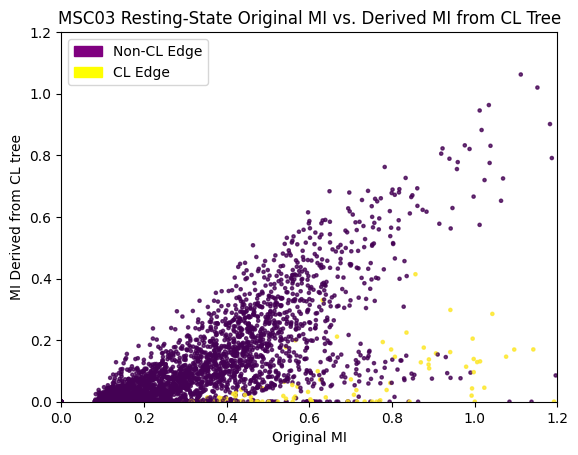

In [27]:
plt.scatter(mi['MSC03'][np.ix_(selected_nodes, selected_nodes)].flatten(), smi_recon.flatten(), c=torch.from_numpy(nx.to_numpy_array(selective_cl_trees['MSC03'])).bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC03 Resting-State Original MI vs. Derived MI from CL Tree")

Text(0.5, 1.0, 'MSC03 Resting-State Original MI vs. Derived MI from CL Tree')

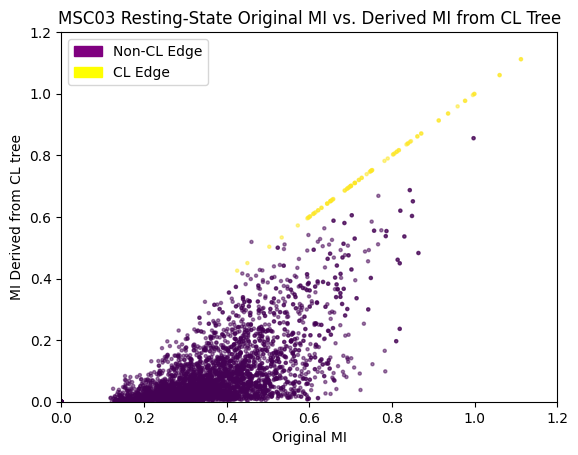

In [87]:
plt.scatter(mi['MSC03'][selected_nodes].flatten(), mi_recon[selected_nodes].flatten(), c=cl_matrices['MSC03'][selected_nodes].bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC03 Resting-State Original MI vs. Derived MI from CL Tree")

In [120]:
smi_recon, sjoint_probs = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, 'MSC03', selective_cl_trees=selective_cl_trees, selected_nodes=selected_nodes)

TypeError: unhashable type: 'list'

# MI calculated:  tensor(0.0298)
parent:  0
[15, 50]
# MI calculated:  tensor(0.0300)
parent:  50
[0, 15]
# MI calculated:  tensor(0.0300)
parent:  15
[0, 51, 37, 50]
# MI calculated:  tensor(0.0310)
parent:  50
[0, 15, 51, 37]
# MI calculated:  tensor(0.0310)
parent:  37
[15, 50, 0, 51]
# MI calculated:  tensor(0.0310)
parent:  51
[15, 55, 50, 37, 0]
# MI calculated:  tensor(0.0318)
parent:  50
[0, 15, 51, 37, 55]
# MI calculated:  tensor(0.0318)
parent:  55
[2, 5, 51, 98, 0, 37, 50, 15]
# MI calculated:  tensor(0.0354)
parent:  50
[0, 15, 51, 37, 55, 2, 5, 98]
# MI calculated:  tensor(0.0354)
parent:  98
[48, 55, 15, 50, 37, 0, 2, 5, 51]
# MI calculated:  tensor(0.0370)
parent:  50
[0, 15, 51, 37, 55, 2, 5, 98, 48]
# MI calculated:  tensor(0.0370)
parent:  48
[98, 49, 51, 5, 2, 0, 37, 50, 15, 55]
# MI calculated:  tensor(0.0388)
parent:  50
[0, 15, 51, 37, 55, 2, 5, 98, 48, 49]
# MI calculated:  tensor(0.0388)
parent:  49
[48, 99, 55, 15, 50, 37, 0, 2, 5, 51, 98]
# MI calculated:  te

Text(0.5, 1.0, 'MSC08 Resting-State Original MI vs. Derived MI from CL Tree')

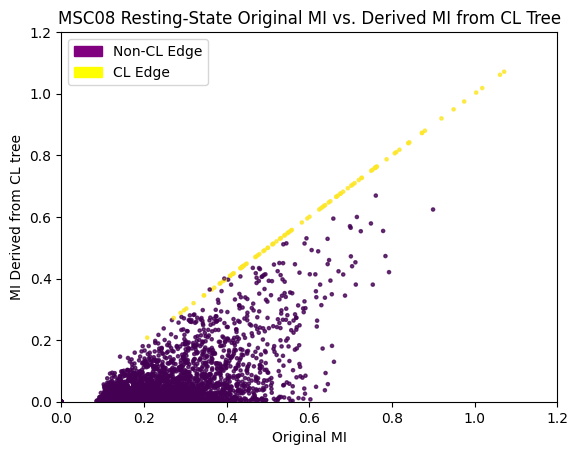

In [67]:
mi_recon_03, joint_probs_03 = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, subject='MSC08')
plt.scatter(mi['MSC08'].flatten(), mi_recon_03.flatten(), c=cl_matrices['MSC08'].bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC08 Resting-State Original MI vs. Derived MI from CL Tree")